In [4]:
data_path = r"C:\PYTHON PROGRAMMING\Lungs Cancer Prediction\data.csv"

df = pd.read_csv(data_path)
df.head()


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [5]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols, cat_cols


(['index',
  'Age',
  'Gender',
  'Air Pollution',
  'Alcohol use',
  'Dust Allergy',
  'OccuPational Hazards',
  'Genetic Risk',
  'chronic Lung Disease',
  'Balanced Diet',
  'Obesity',
  'Smoking',
  'Passive Smoker',
  'Chest Pain',
  'Coughing of Blood',
  'Fatigue',
  'Weight Loss',
  'Shortness of Breath',
  'Wheezing',
  'Swallowing Difficulty',
  'Clubbing of Finger Nails',
  'Frequent Cold',
  'Dry Cough',
  'Snoring'],
 ['Patient Id', 'Level'])

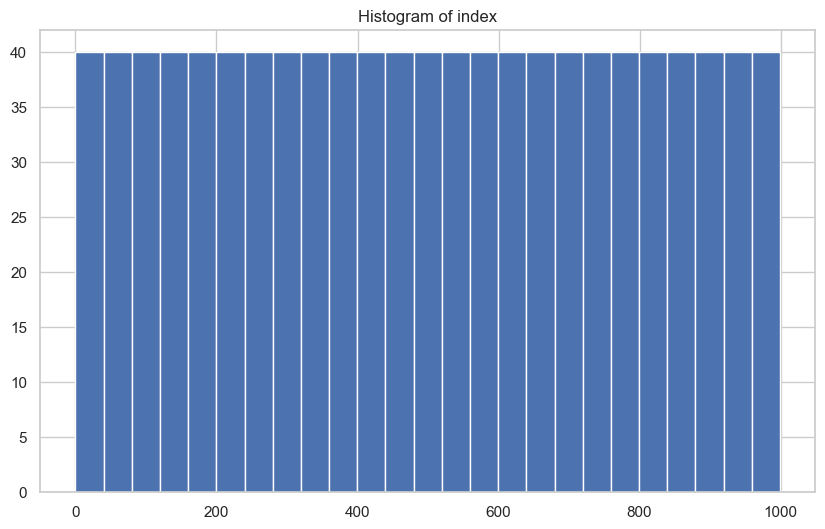

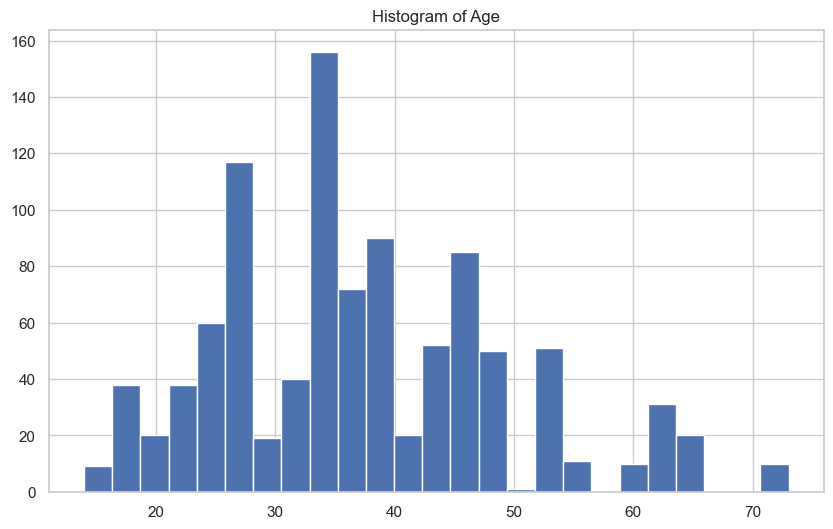

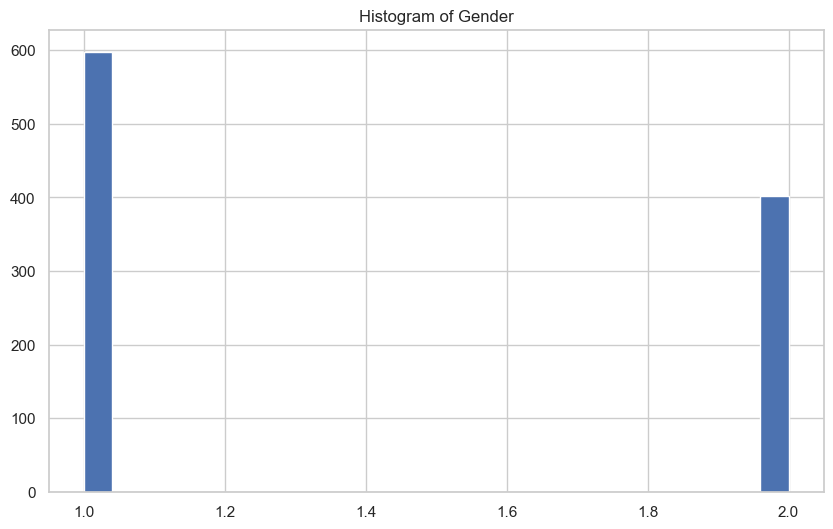

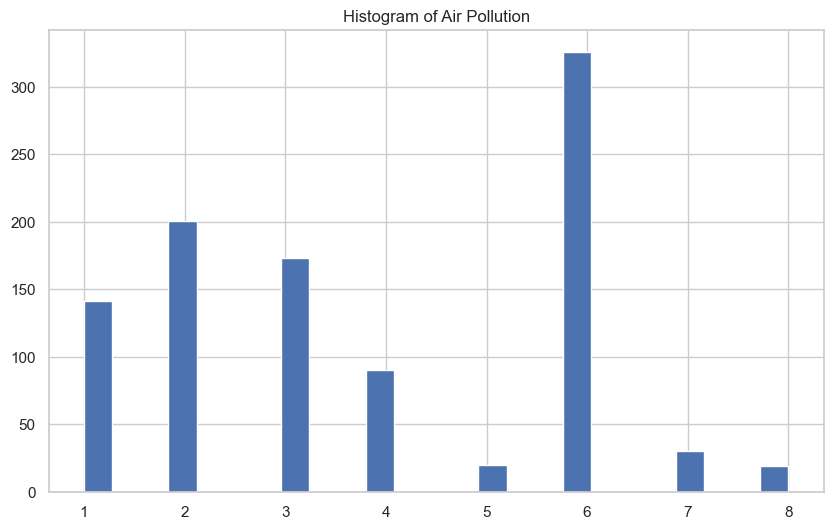

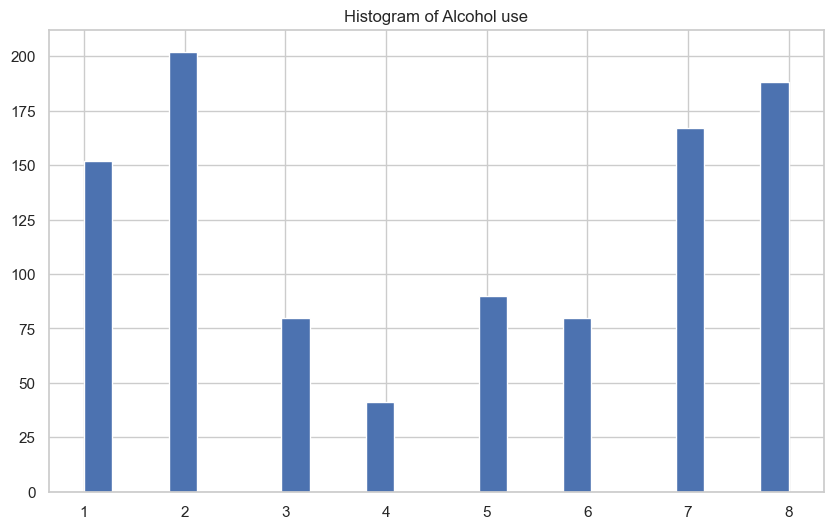

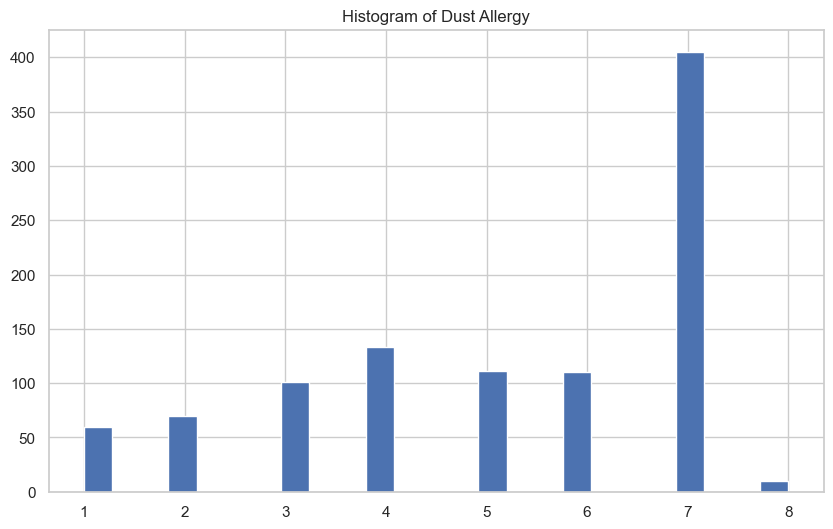

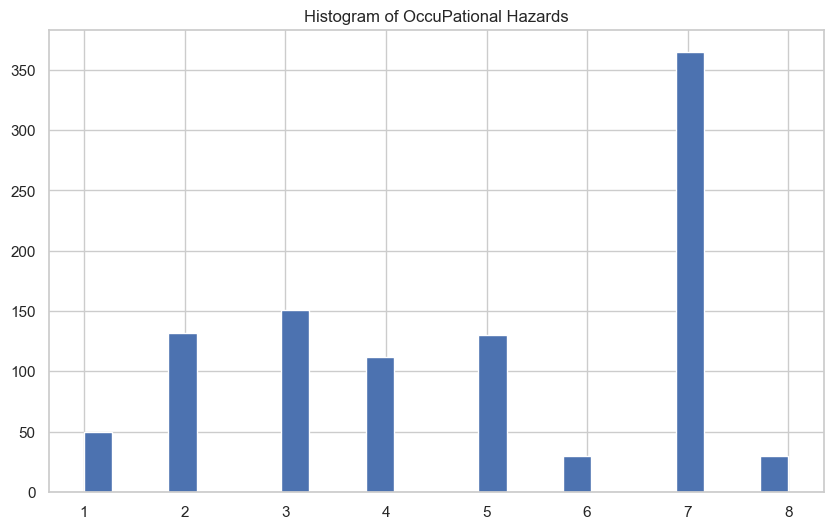

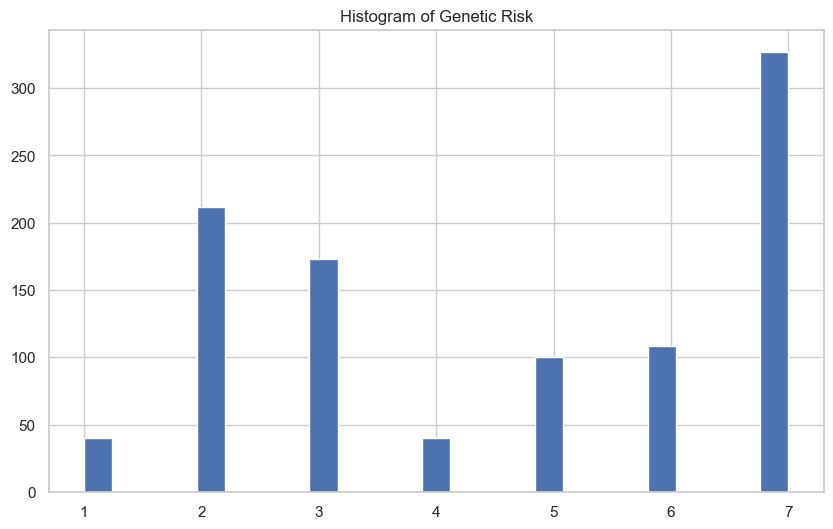

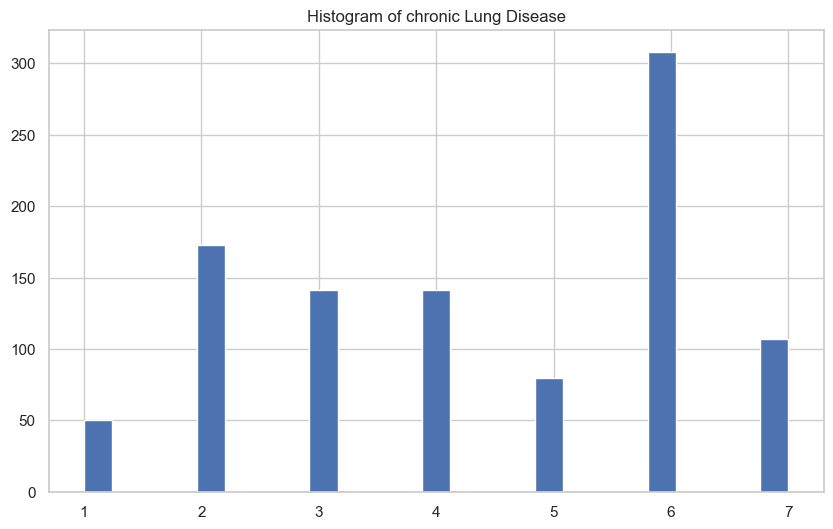

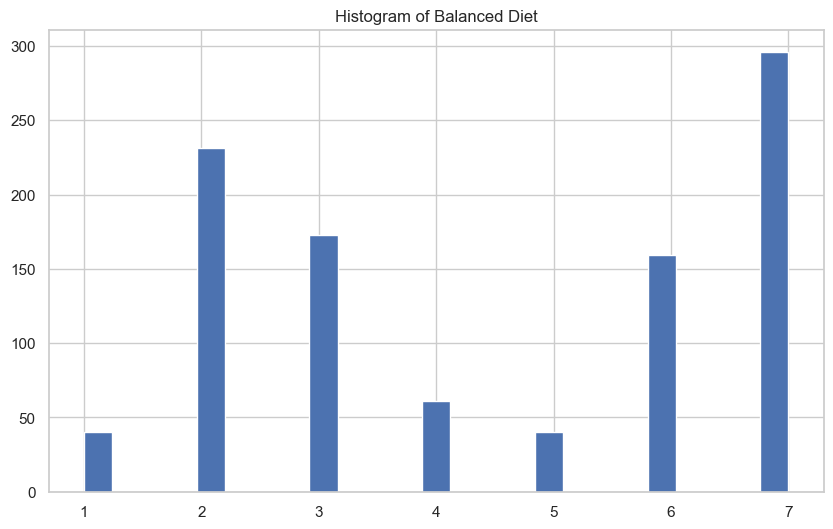

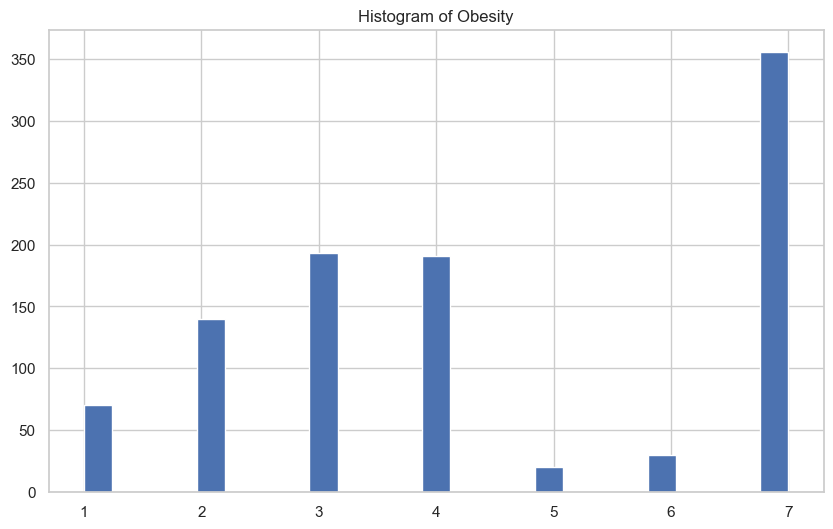

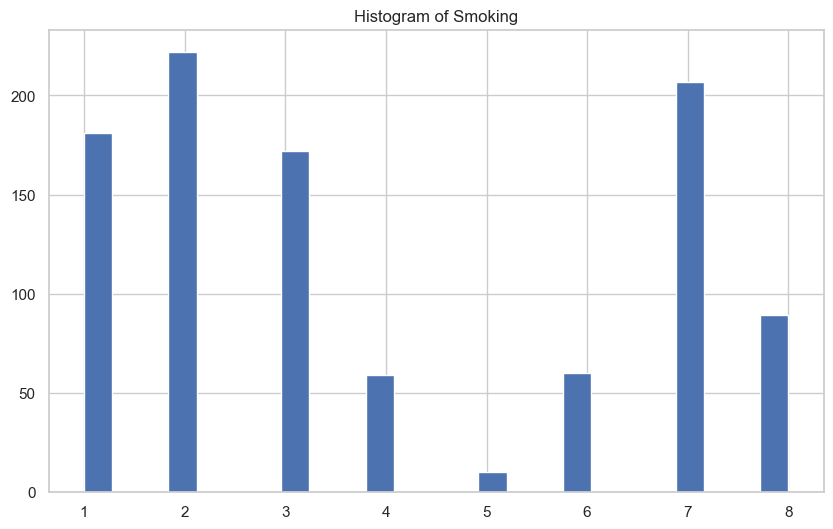

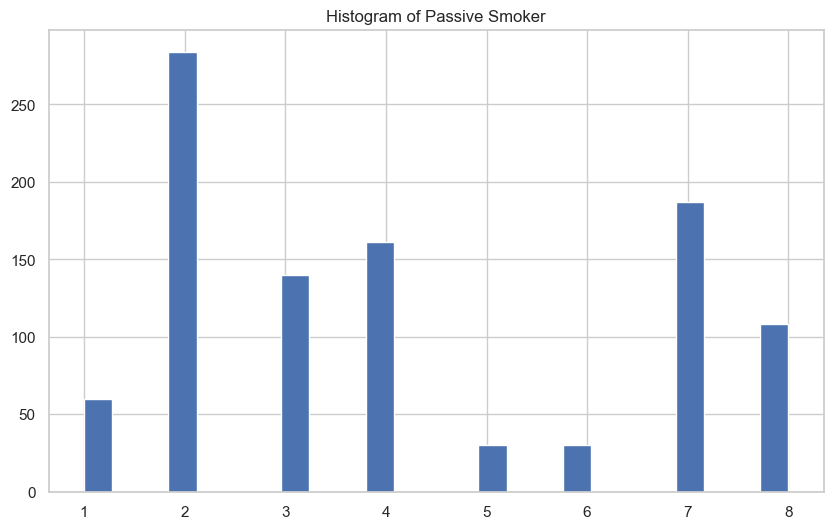

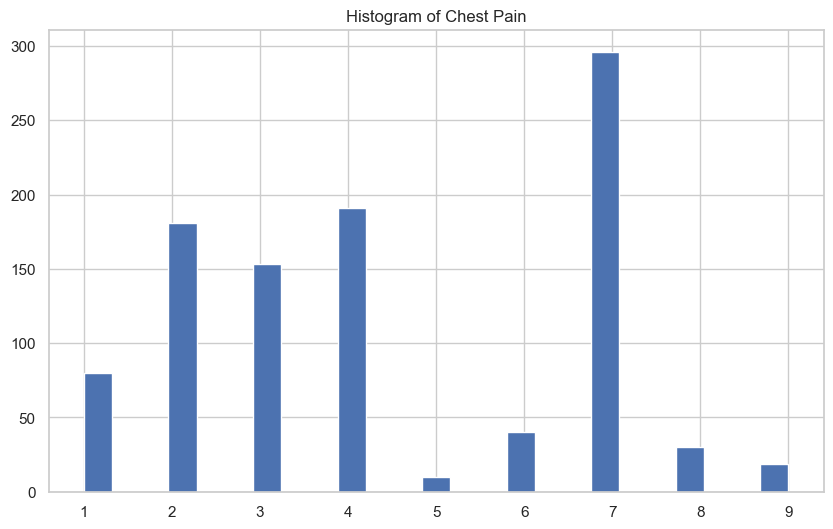

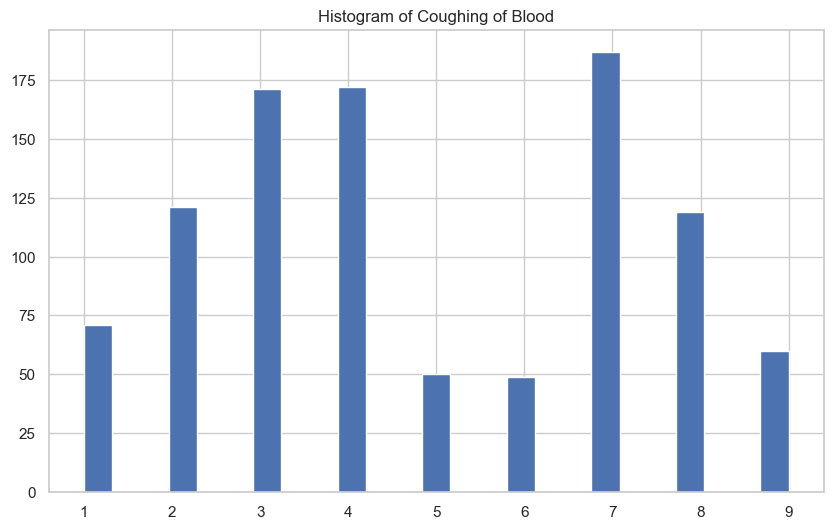

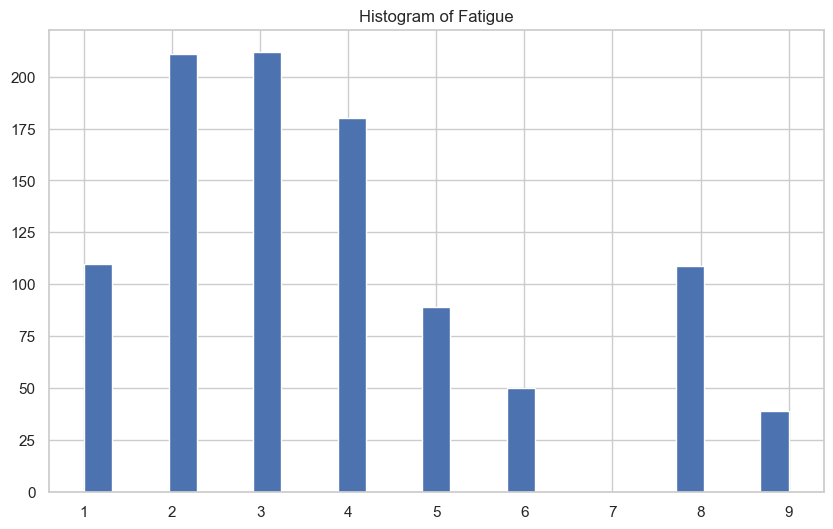

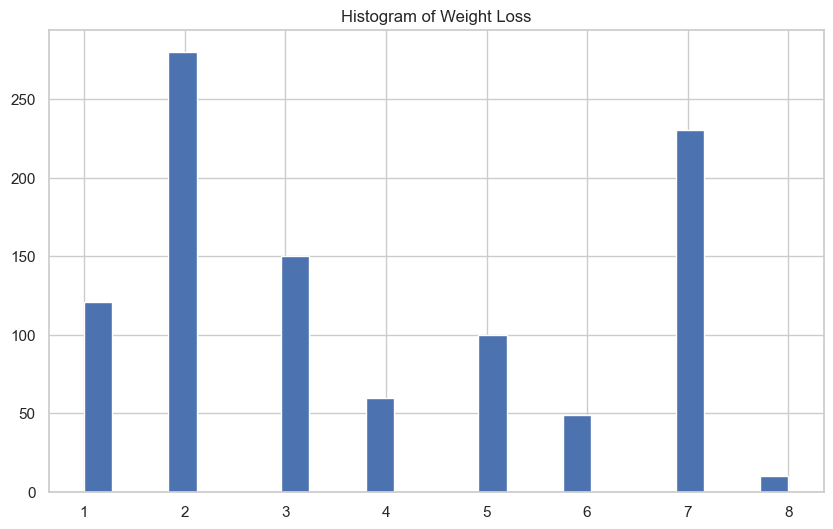

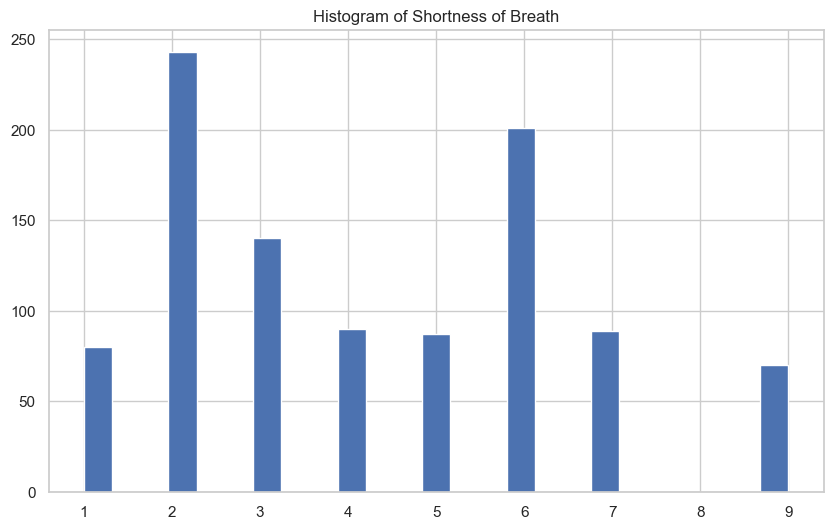

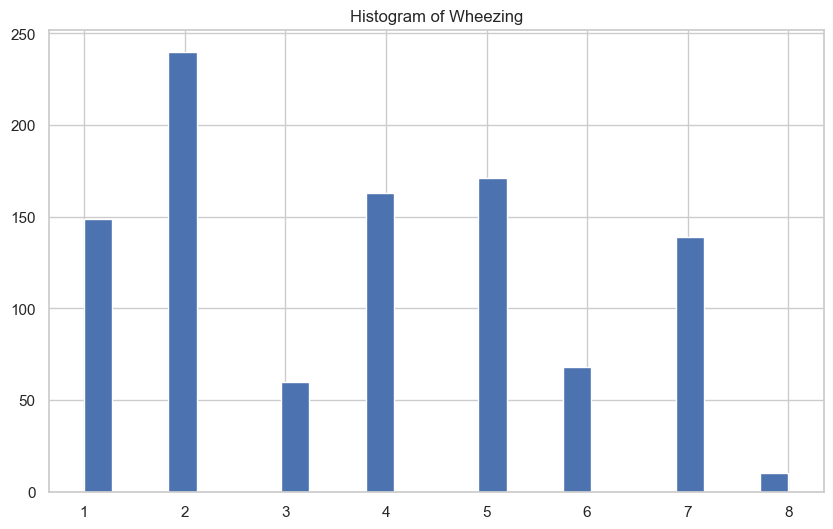

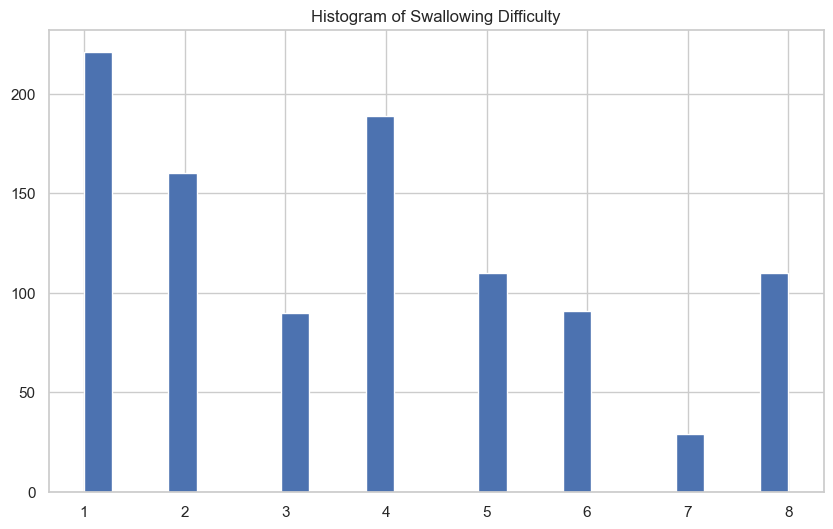

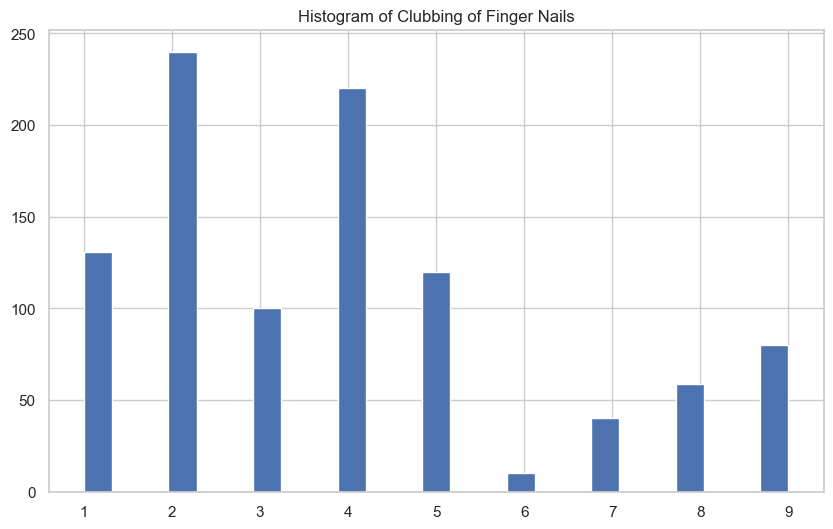

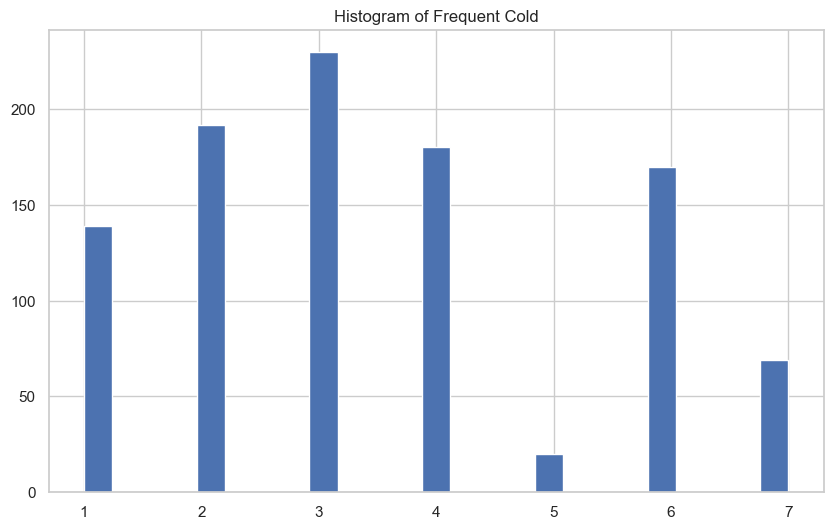

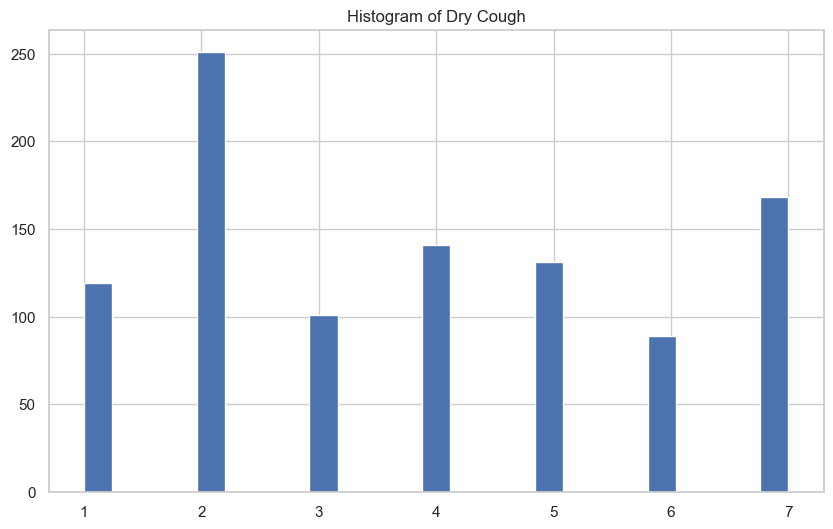

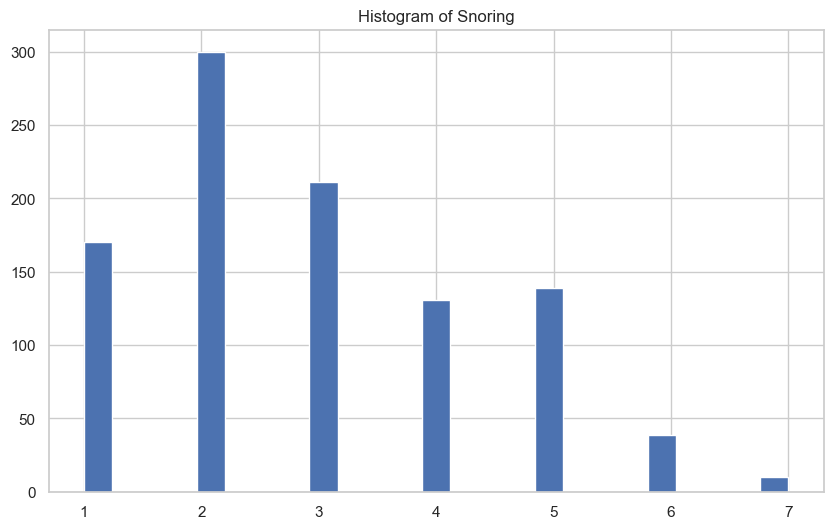

In [7]:
for col in num_cols:
    plt.figure()
    df[col].hist(bins=25)
    plt.title(f"Histogram of {col}")
    plt.show()


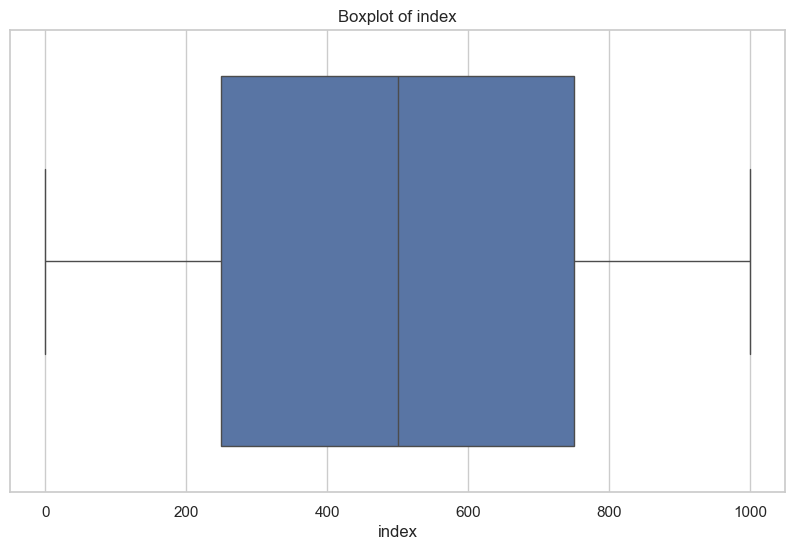

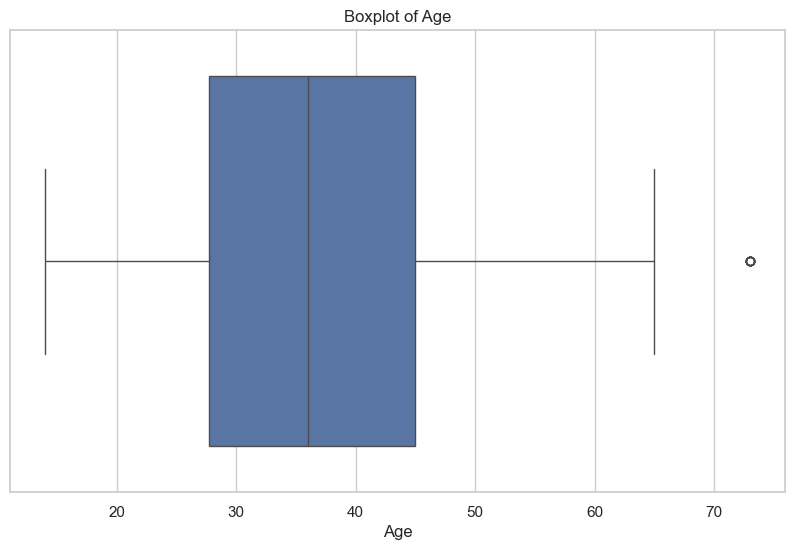

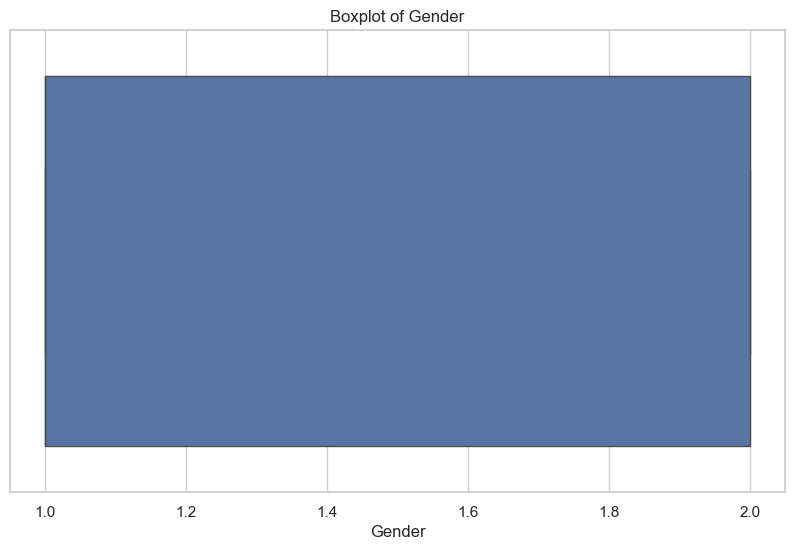

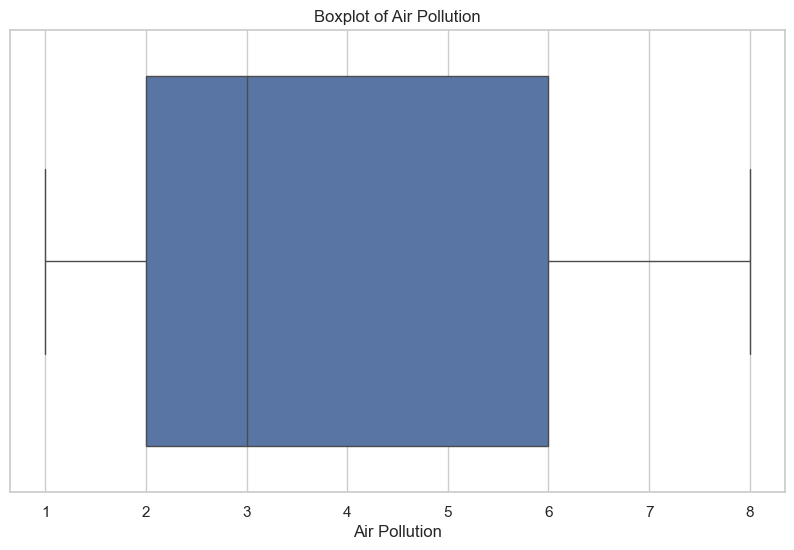

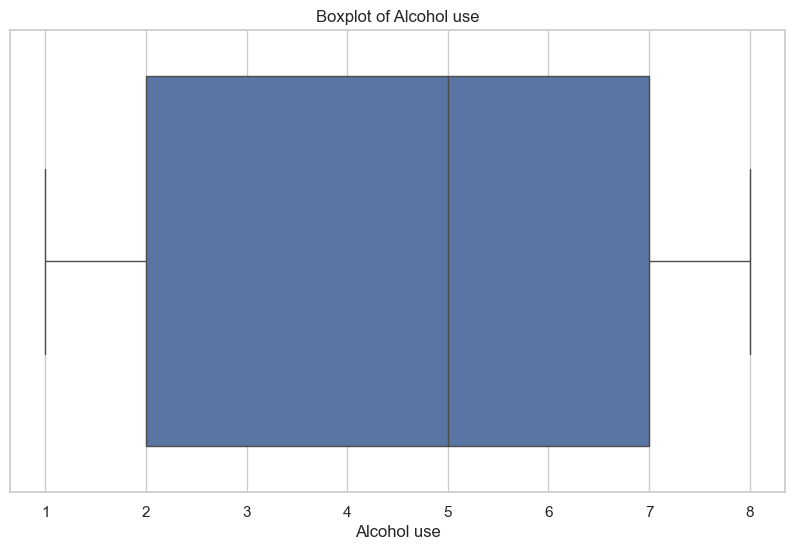

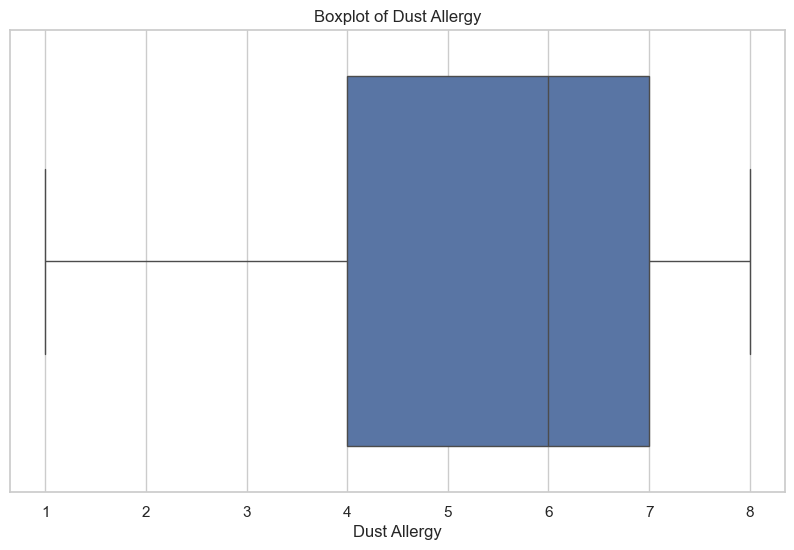

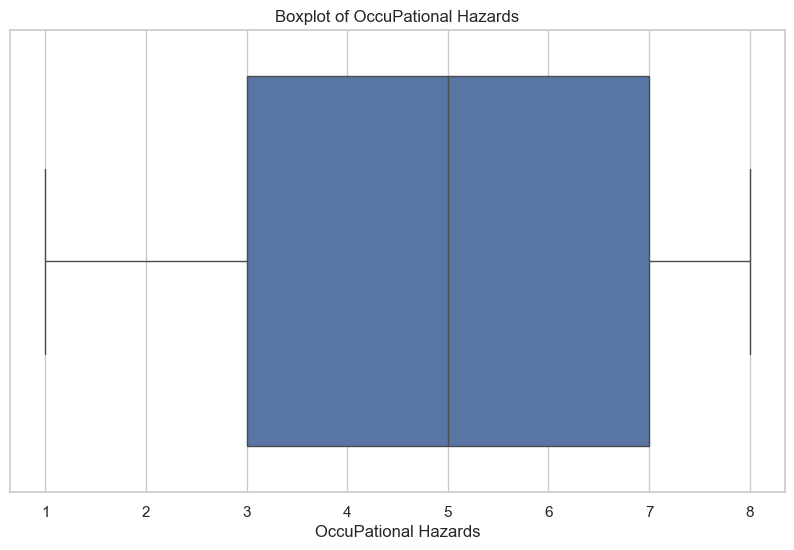

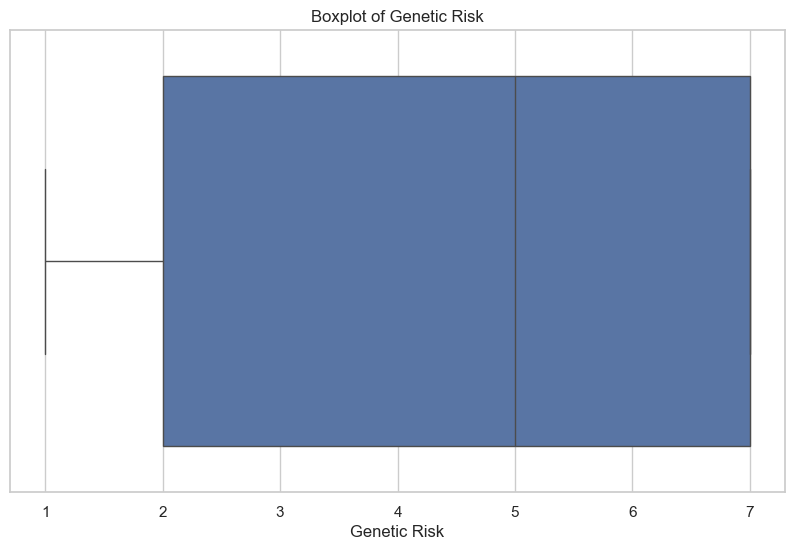

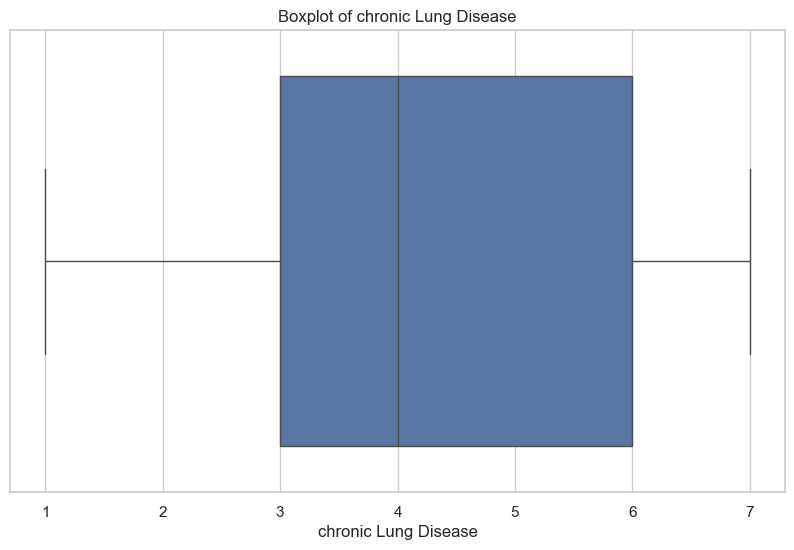

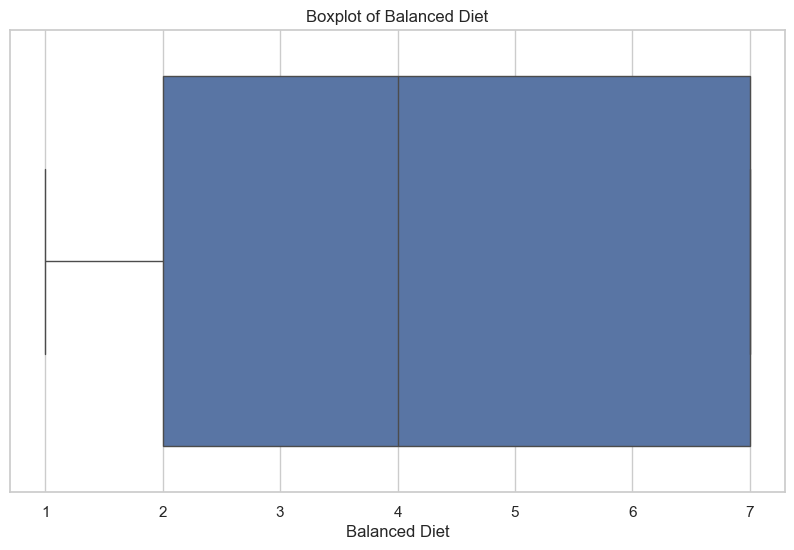

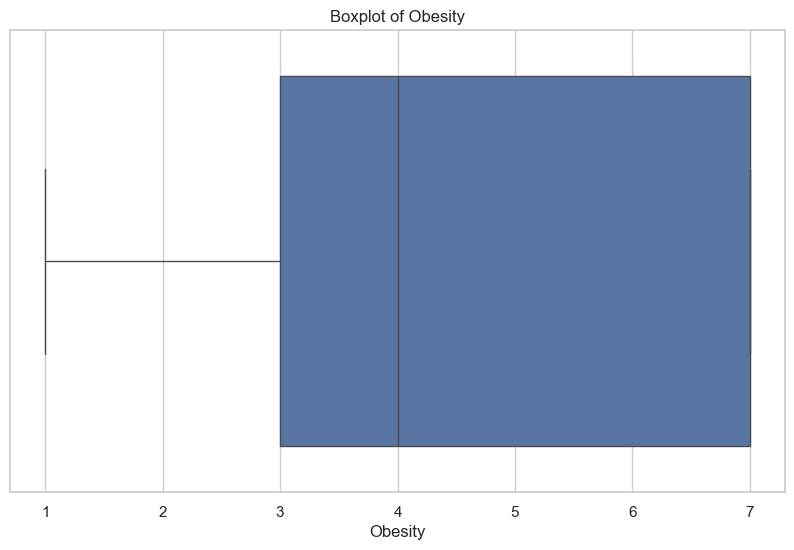

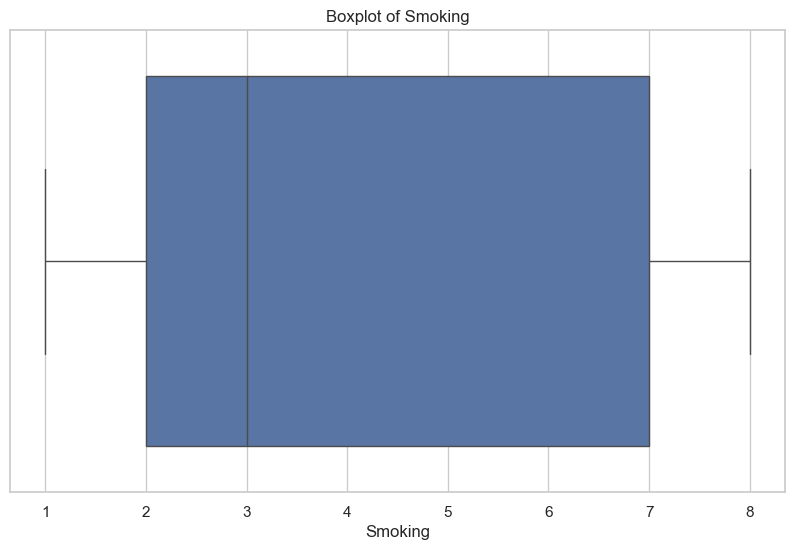

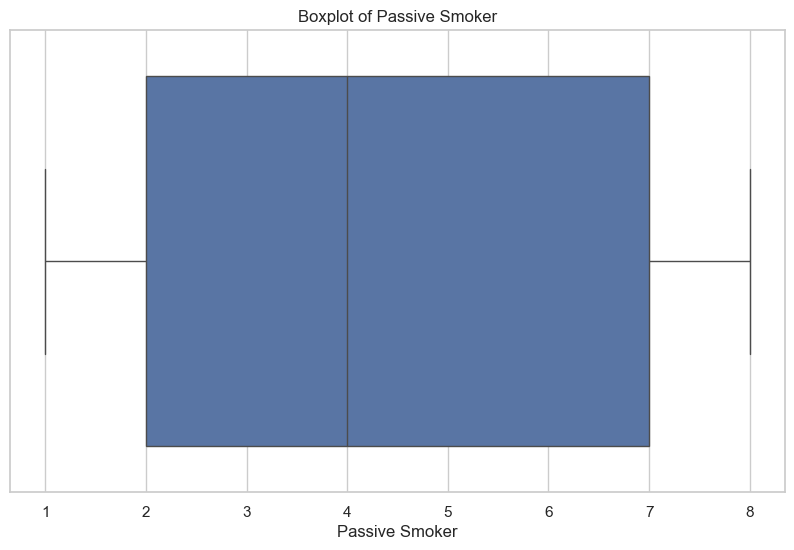

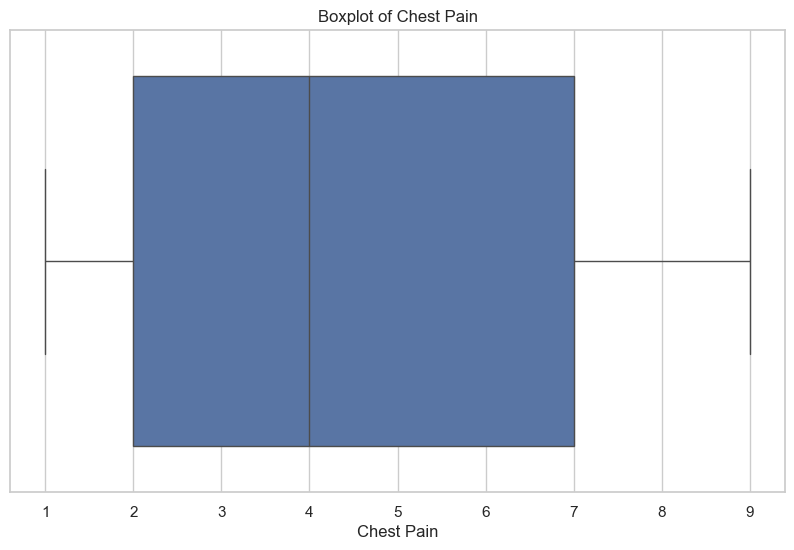

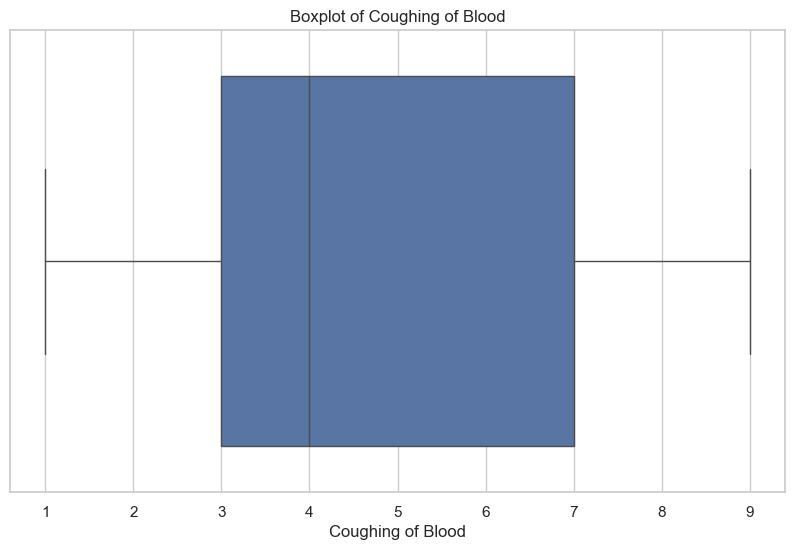

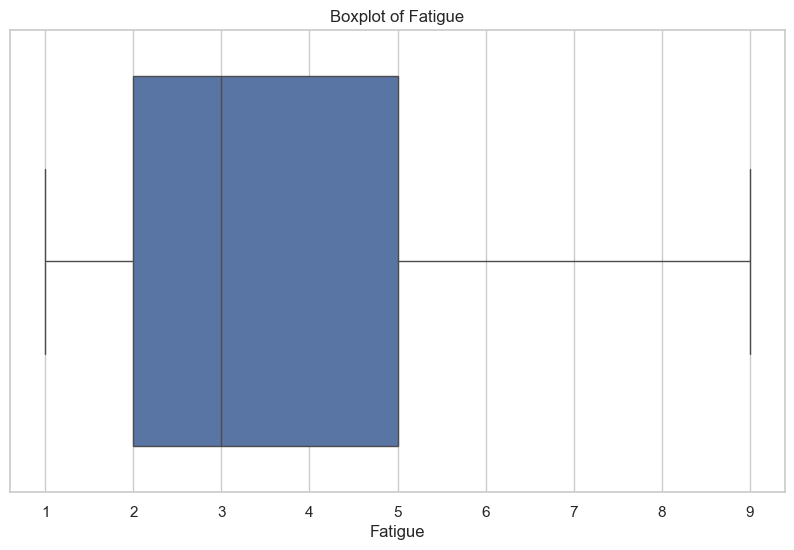

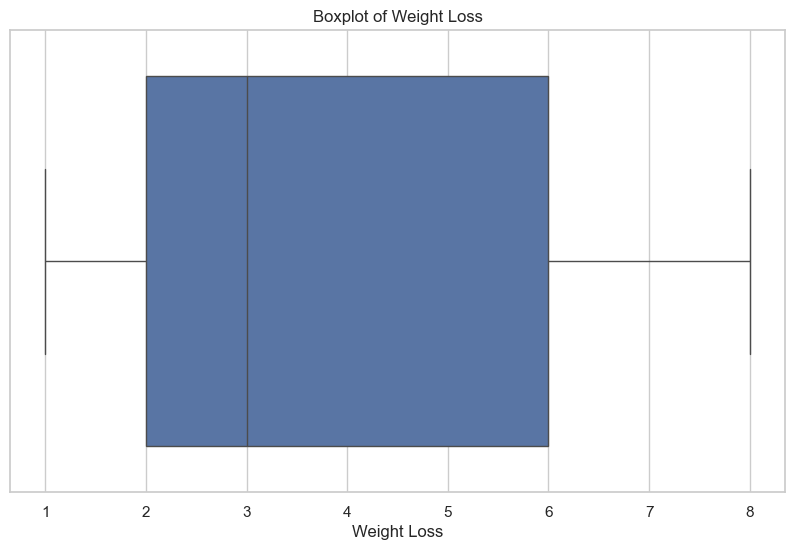

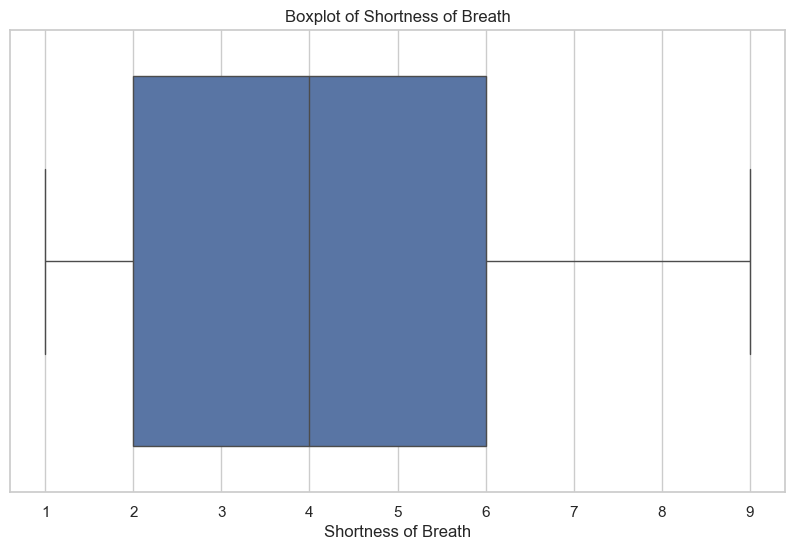

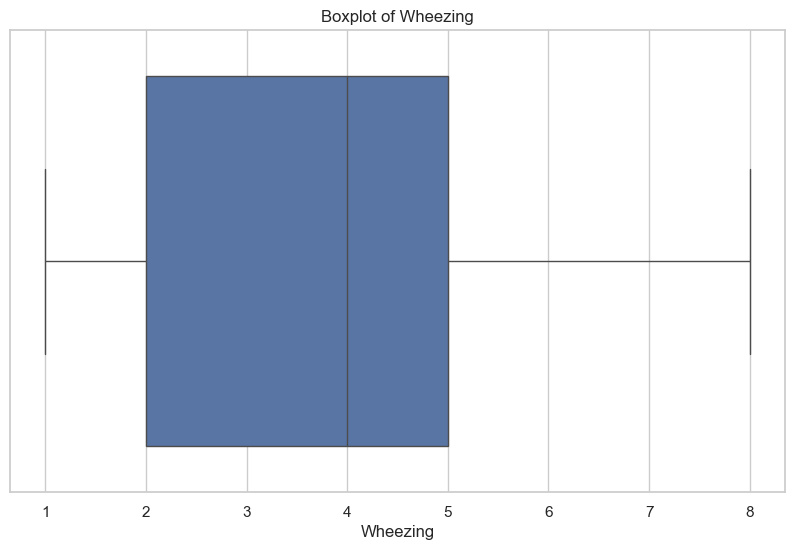

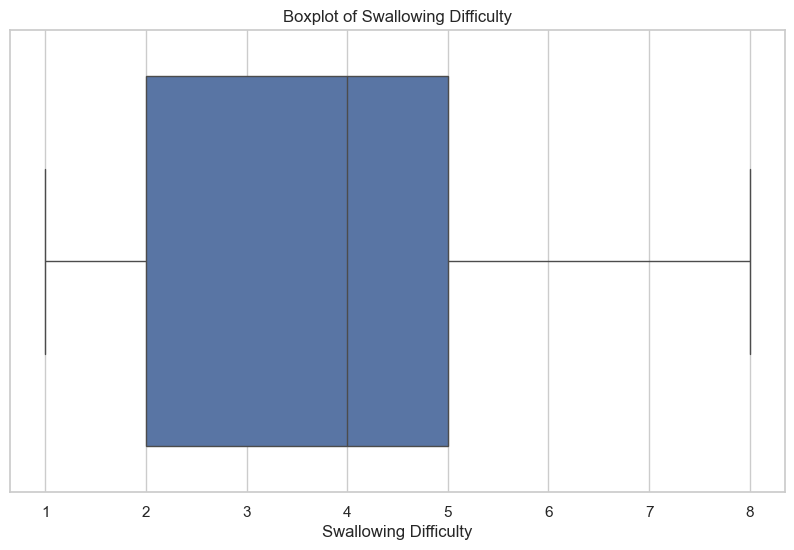

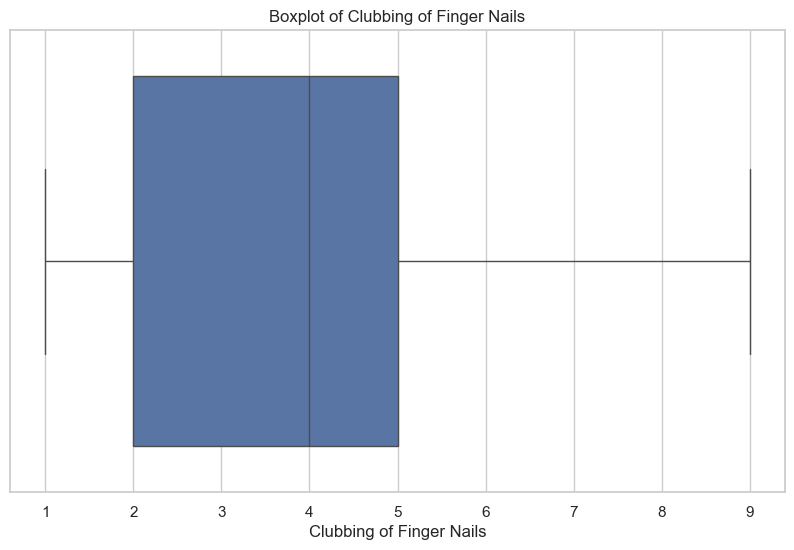

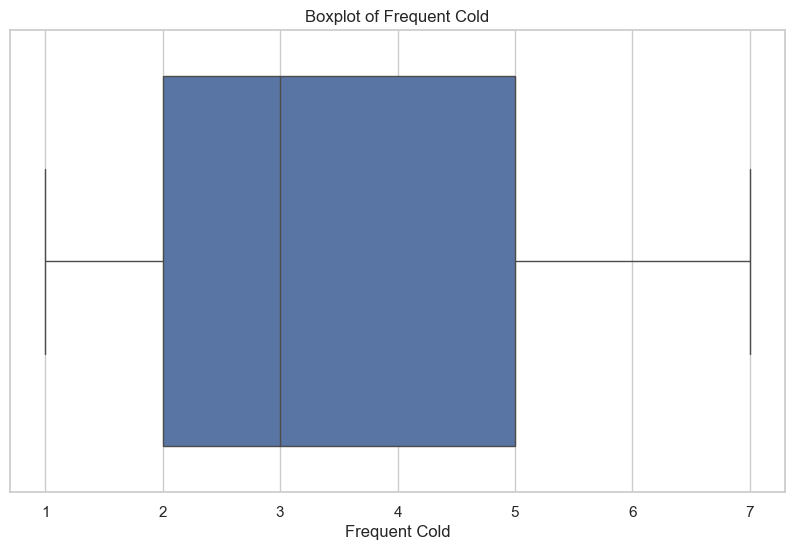

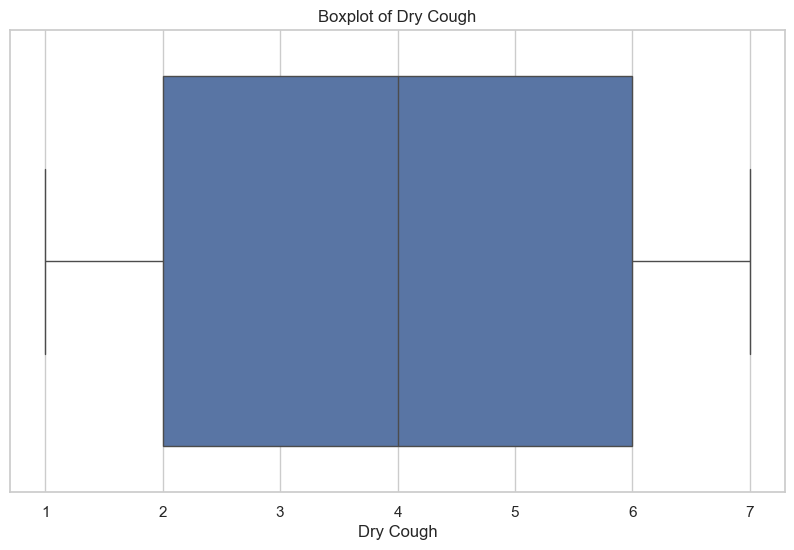

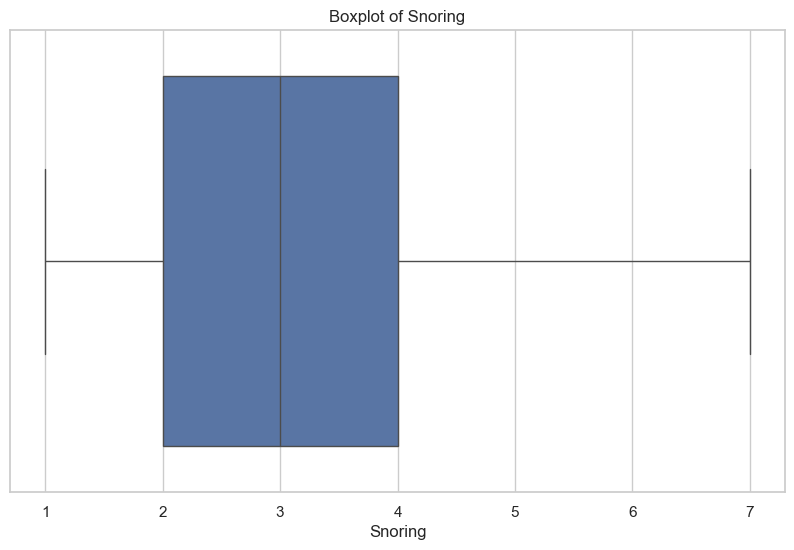

In [8]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


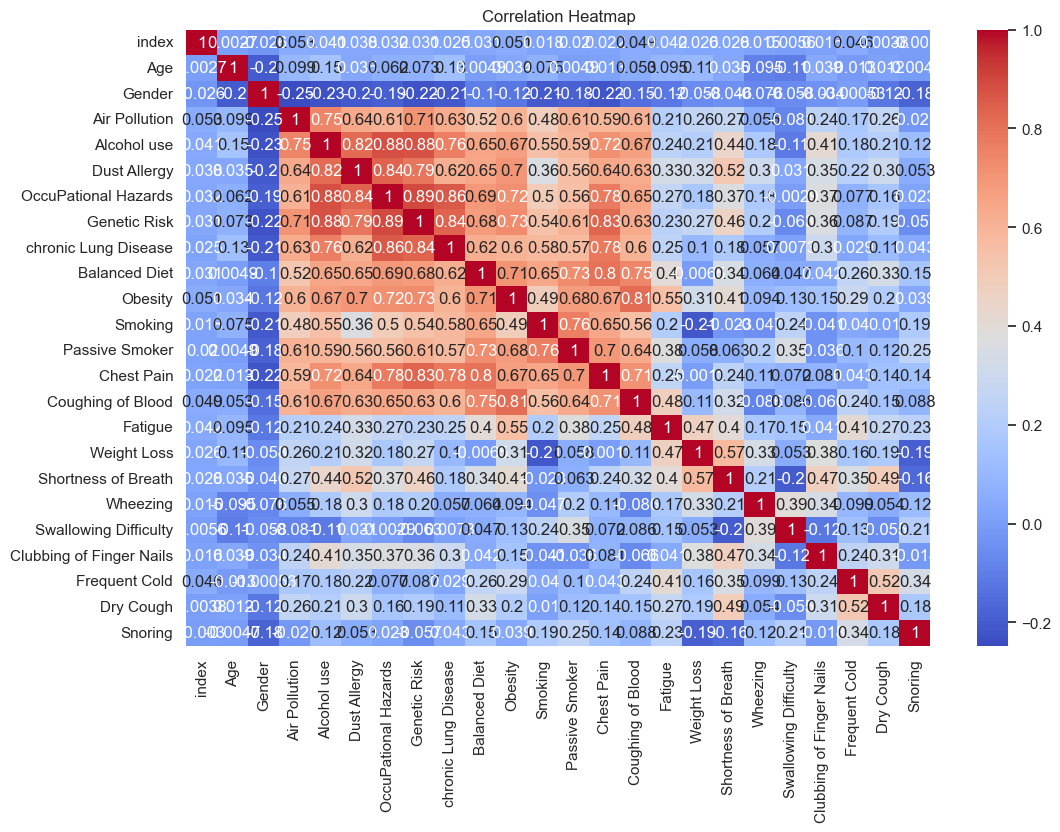

In [9]:
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [10]:
df_clean = df.copy()

imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

for col in cat_cols:
    if df_clean[col].nunique() <= 2:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    else:
        df_clean = pd.get_dummies(df_clean, columns=[col], drop_first=True)

df_clean.head()


,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Patient Id_P992,Patient Id_P993,Patient Id_P994,Patient Id_P995,Patient Id_P996,Patient Id_P997,Patient Id_P998,Patient Id_P999,Level_Low,Level_Medium
0,0.0,33.0,1.0,2.0,4.0,5.0,4.0,3.0,2.0,2.0,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.0,1.0,3.0,1.0,5.0,3.0,4.0,2.0,2.0,...,False,False,False,False,False,False,False,False,False,True
2,2.0,35.0,1.0,4.0,5.0,6.0,5.0,5.0,4.0,6.0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,37.0,1.0,7.0,7.0,7.0,7.0,6.0,7.0,7.0,...,False,False,False,False,False,False,False,False,False,False
4,4.0,46.0,1.0,6.0,8.0,7.0,7.0,7.0,6.0,7.0,...,False,False,False,False,False,False,False,False,False,False


In [11]:
target_col = df_clean.columns[-1]   # assuming last column is the label

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X.head(), y.head()


(   index   Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
 0    0.0  33.0     1.0            2.0          4.0           5.0   
 1    1.0  17.0     1.0            3.0          1.0           5.0   
 2    2.0  35.0     1.0            4.0          5.0           6.0   
 3    3.0  37.0     1.0            7.0          7.0           7.0   
 4    4.0  46.0     1.0            6.0          8.0           7.0   
 
    OccuPational Hazards  Genetic Risk  chronic Lung Disease  Balanced Diet  \
 0                   4.0           3.0                   2.0            2.0   
 1                   3.0           4.0                   2.0            2.0   
 2                   5.0           5.0                   4.0            6.0   
 3                   7.0           6.0                   7.0            7.0   
 4                   7.0           7.0                   6.0            7.0   
 
    ...  Patient Id_P991  Patient Id_P992  Patient Id_P993  Patient Id_P994  \
 0  ...            False     

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()


,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Patient Id_P991,Patient Id_P992,Patient Id_P993,Patient Id_P994,Patient Id_P995,Patient Id_P996,Patient Id_P997,Patient Id_P998,Patient Id_P999,Level_Low
0,-1.730320,-0.347848,-0.819903,-0.906679,-0.214954,-0.083340,-0.398718,-0.743202,-1.288162,-1.167040,...,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,1.516684
1,-1.726856,-1.681238,-0.819903,-0.413919,-1.360357,-0.083340,-0.873383,-0.272821,-1.288162,-1.167040,...,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.659333
2,-1.723391,-0.181174,-0.819903,0.078842,0.166847,0.421751,0.075946,0.197560,-0.205673,0.706970,...,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.659333
3,-1.719927,-0.014501,-0.819903,1.557123,0.930449,0.926842,1.025275,0.667941,1.418061,1.175473,...,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.659333
4,-1.716463,0.735531,-0.819903,1.064362,1.312250,0.926842,1.025275,1.138323,0.876816,1.175473,...,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.031639,-0.659333


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, prob) if prob is not None else None
    })

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.940,1.0,0.818182,0.900000,0.944934
1,RandomForest,1.000,1.0,1.000000,1.000000,1.000000
2,SVM,0.695,1.0,0.075758,0.140845,0.891904
3,KNN,1.000,1.0,1.000000,1.000000,1.000000


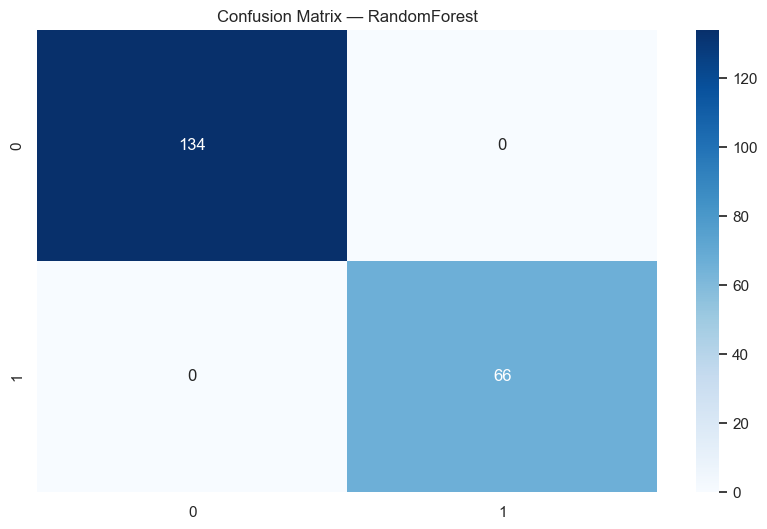

In [15]:
best_model_name = max(results, key=lambda x: x["Accuracy"])["Model"]
best_model = models[best_model_name]

cm = confusion_matrix(y_test, best_model.predict(X_test))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


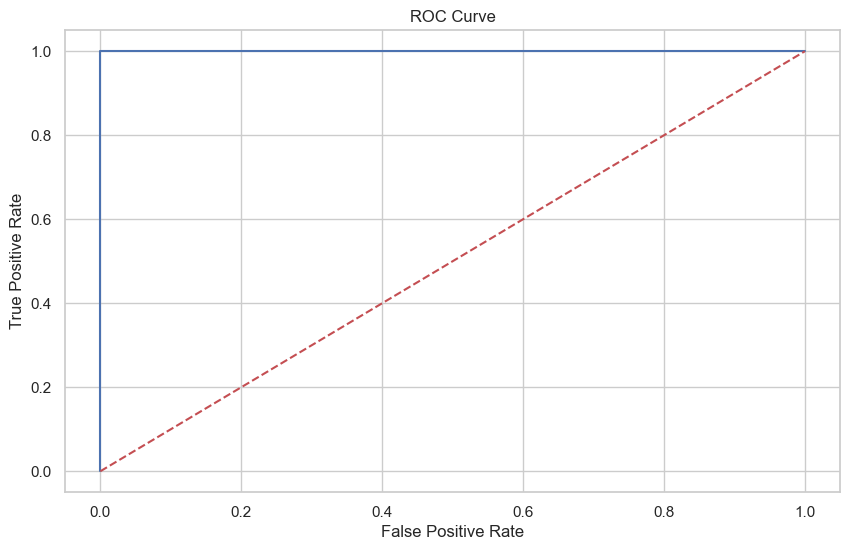

1.0

In [16]:
probs = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'r--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

roc_auc_score(y_test, probs)


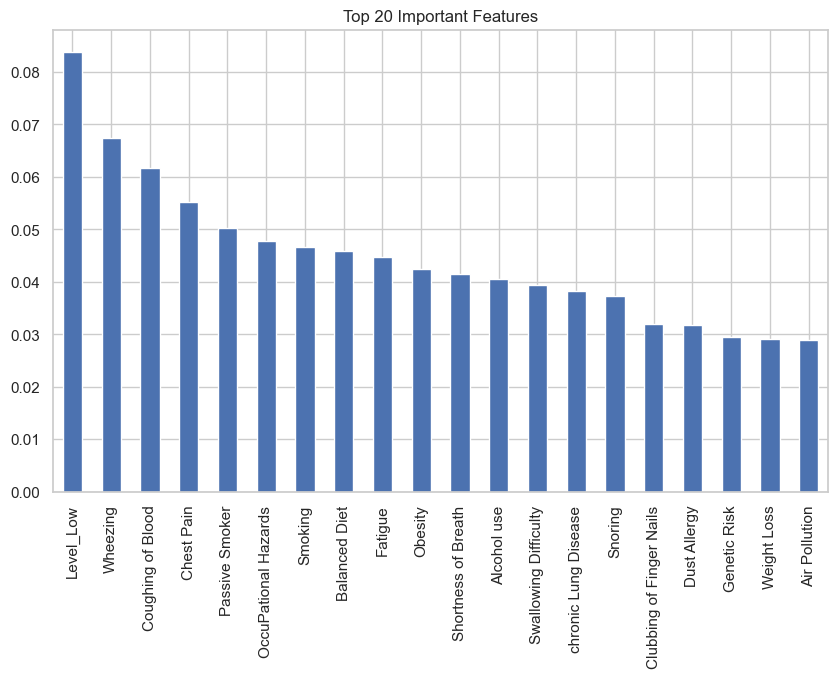

In [17]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(20).plot(kind='bar')
plt.title("Top 20 Important Features")
plt.show()


In [18]:
param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [None,5,10],
    "min_samples_split": [2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_


({'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50},
 np.float64(1.0))

In [19]:
best_rf = grid.best_estimator_
preds = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       134
        True       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [20]:
model_path = r"C:\PYTHON PROGRAMMING\Lungs Cancer Prediction\lung_cancer_rf_model.joblib"
scaler_path = r"C:\PYTHON PROGRAMMING\Lungs Cancer Prediction\lung_cancer_scaler.joblib"

joblib.dump(best_rf, model_path)
joblib.dump(scaler, scaler_path)

print("Model saved at:", model_path)


Model saved at: C:\PYTHON PROGRAMMING\Lungs Cancer Prediction\lung_cancer_rf_model.joblib


In [21]:
sample = X_test.iloc[0:1]
prob = best_rf.predict_proba(sample)[0][1]
pred = best_rf.predict(sample)[0]

prob, pred


(np.float64(0.0), np.False_)

In [22]:
!pip install pillow


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
